In [1]:
using FluorescenceCorrelationFitting

In [2]:
filepath = "sample2.pqres"
data = read_fcs(filepath);

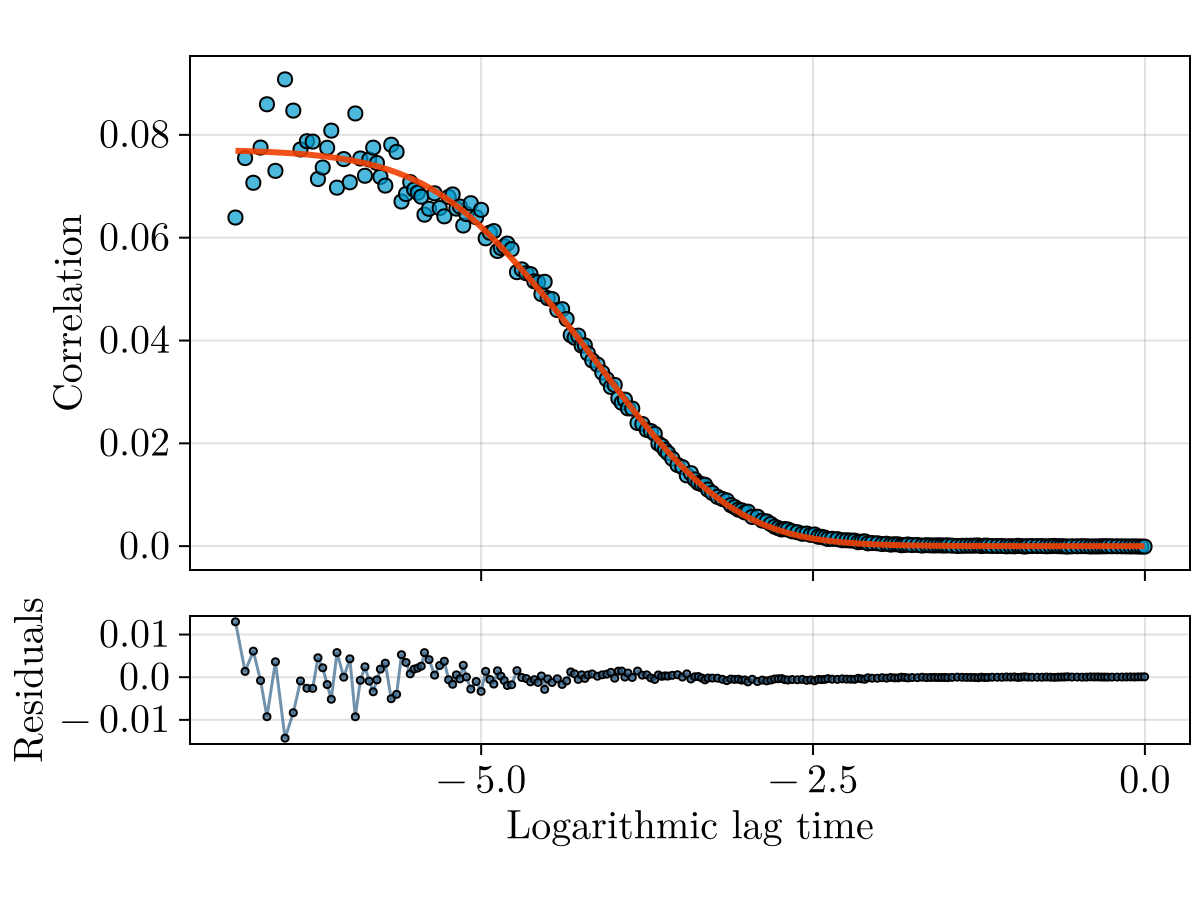

In [3]:
using CairoMakie, LaTeXStrings

offset=0.0
spec = FCSModelSpec(dim = FluorescenceCorrelationFitting.d3, anom = FluorescenceCorrelationFitting.none, offset = offset)

initial_parameters = [0.05, 6, 5e-4, 1e-4, 0.5]
lower_bounds = [0.01, 0.1, 1e-4, 1e-5, 0.0]
upper_bounds = [0.1, 20, 2e-3, 5e-3, 1.0]
fit = fcs_fit(spec, data.channels[1], initial_parameters; lower = lower_bounds, upper = upper_bounds)
fig, _ = fcs_plot(fit, data.channels[1])
fig

In [4]:
using PrettyTables

fcs_table(fit; units=["", "", "μ", "μ", ""], gof_metric=aic)

Parameters 
 Values 
 Std. Dev. 
 
 
 
 
 Current amplitude 
 0.0772 
 0.2458 
 
 
 Structure factor 
 0.2198 
 27.92 
 
 
 Residence time [μs] 
 805.1 
 8.982e+4 
 
 
 Dynamic lifetime 1 [μs] 
 10 
 2038 
 
 
 Dynamic population fraction 1 
 0.138 
 33.13 
 
 
 
 
 aic = -1583.57

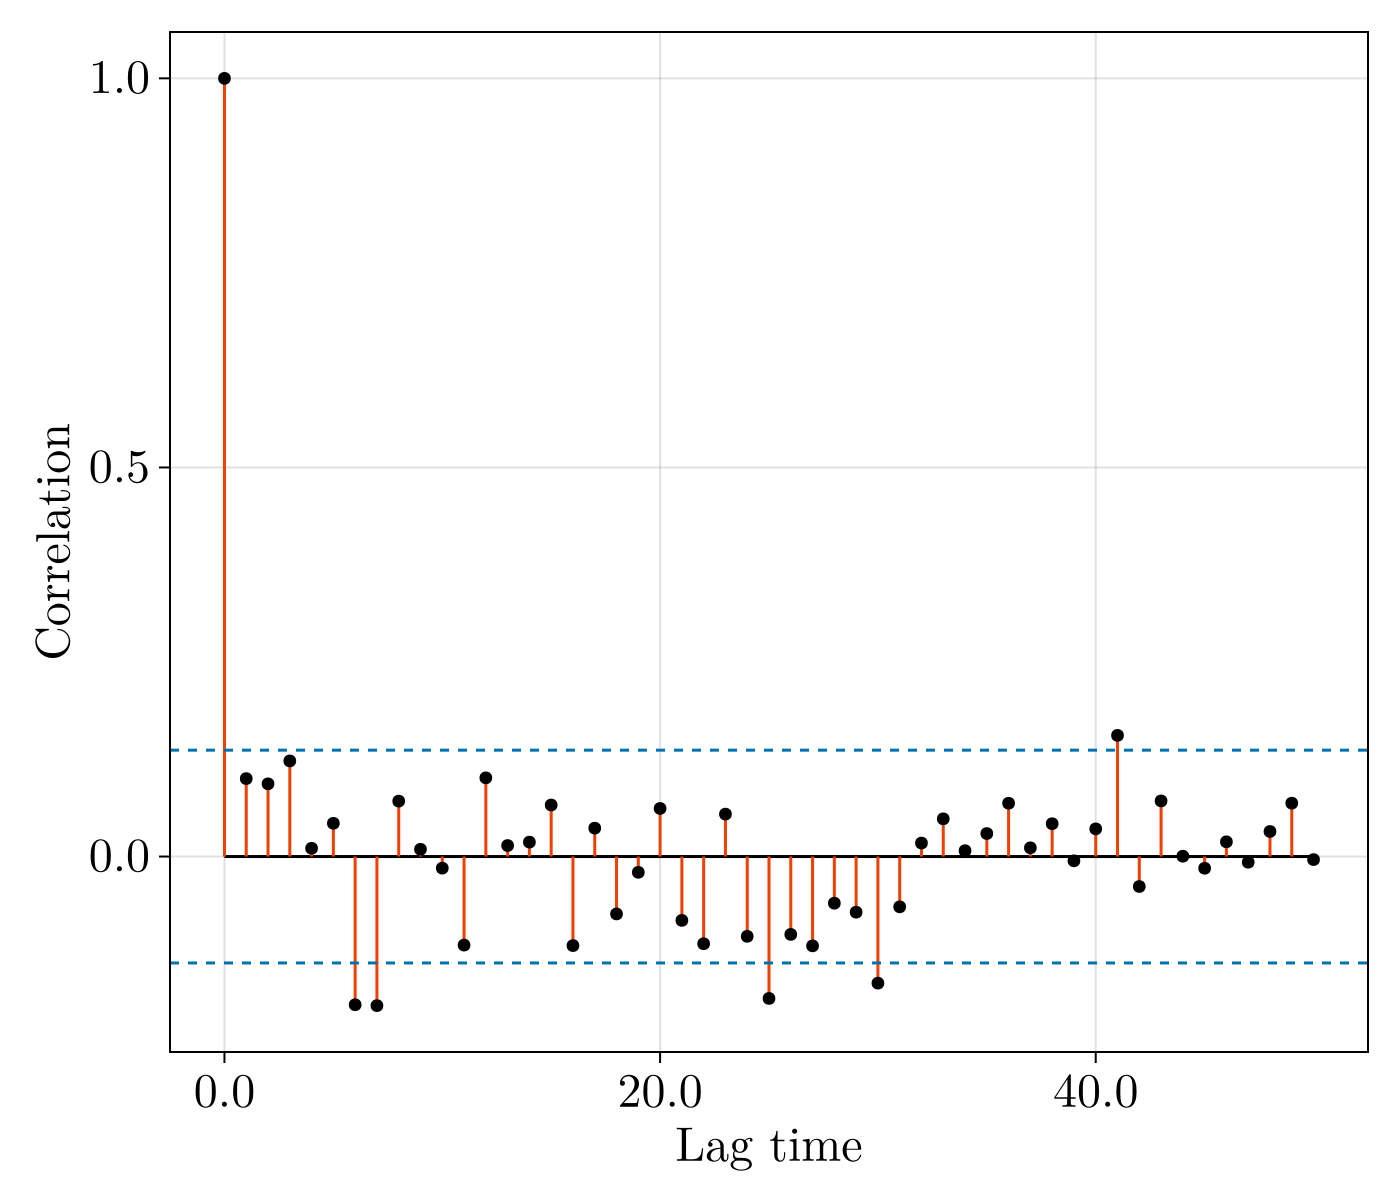

In [5]:
fig = resid_acf_plot(fit; 
    acf_kwargs=(maxlag=50,), 
    plot_kwargs=(
        figure_kw=(size=(700,600),fontsize=24), 
        stem_kw=(stemcolor=:orangered2, color=:black, trunkcolor=:black), 
        hline_kw=(linestyle=:dash,)
    )
)
fig